In [ ]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(patchwork)
    library(future)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [ ]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/load.code.env.R")


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers




In [ ]:
path_ref <- '/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_scglue_embbeding.rds'
dmg <- readRDS(path_ref)
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
dmg <- AddMetaData(dmg, readRDS('../data/dmg_atlas_final_annotation.rds'))

In [ ]:
dmg$lvl_4 <- droplevels(recode(dmg$lvl_4,
                   'cEndo'='Endothelial', 
'vEndo'='Endothelial', 
'aEndo'='Endothelial', 
'Endo_peri_2'='Endothelial', 
'CD4_naive'='T_cell', 
'CD8_effector'='T_cell', 
'CD8_early_exhaustion'='T_cell', 
'CD8_naive'='T_cell', 
'Plasma_B'='B_cell', 
'NK'='T_cell', 
'B_naive'='B_cell', 
'CD8_proliferative'='T_cell',  
'B_activated'='B_cell', 
'OPC'='OPC', 
'Astrocyte_fibrous'='Astrocyte', 
'Astrocyte_protoplasmic'='Astrocyte', 
'Peri_2'='Mural', 
'Fibro_type_1'='Mural', 
'Fibro_type_2'='Mural', 
'Peri_1'='Mural', 
'Fibro_type_3'='Mural', 
'SMC'='Mural', 
'Splatter'='Neuron', 
'Upper_rhomboic_lip'='Neuron', 
'Upper_layer_intratelencephalic'='Neuron', 
'Lower_rhomboic_lip'='Neuron', 
'Deep_layer_intratelencephalic'='Neuron', 
'Oligo_2'='Oligodendrocyte', 
'Oligo_1'='Oligodendrocyte',
                                'MG_homeostatic'='TAM_homeostatic',
                               'MDM_C1Q'='TAM_C1Q',
                               'MG_C1Q'='TAM_C1Q',
                               'MDM_lipid_metab'='TAM_lipid_laden',
                               'MG_lipid_metab'='TAM_lipid_laden',
                               'MG_IL1B'='TAM_IL1B',
                               'Neutrophil'='Mono_neutrophil',
                               'Monocyte'='Mono_neutrophil',
                               'MDM_scavenger'='TAM_scavenger',
                                'Dedifferentiated'='TD_like',
                                'GW_dedifferentiated'='GB_like',
                                'IPC_like'='nIPC_like'
))


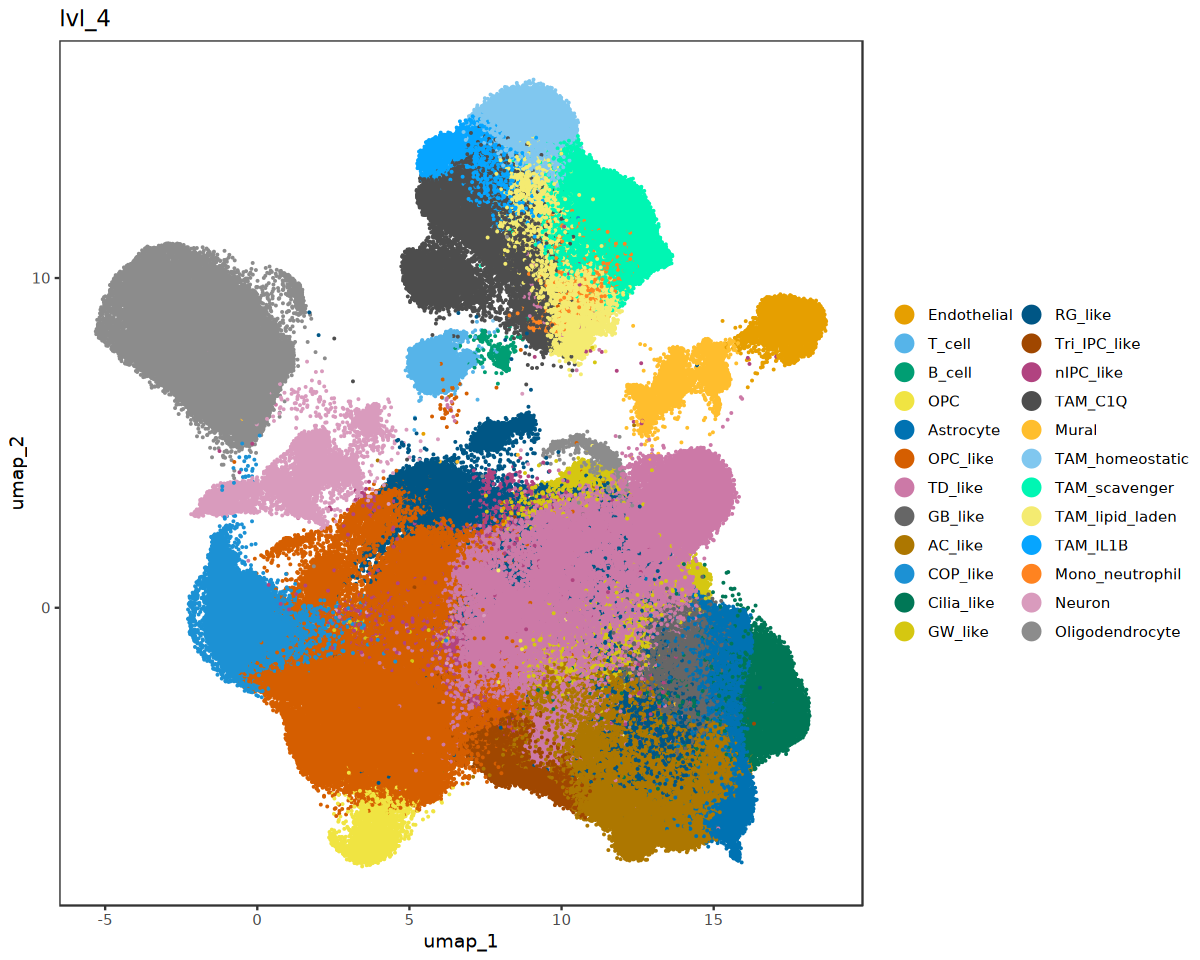

In [ ]:
options(repr.plot.height = 8, repr.plot.width = 10)
dittoDimPlot(dmg, 
             reduction.use = "umap", var = "lvl_4", 
             size = 0.5)

In [ ]:
dmg <- subset(dmg, Study=='Ruiz2023')
dmg

An object of class Seurat 
19248 features across 205805 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
dmg <-  subset(dmg, lvl_2 %in% c('Stem_like',
                                  'Differentiated_like',
                                  'Myeloid'))

In [ ]:
dmg

An object of class Seurat 
19248 features across 159189 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
sussman2024_malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_malignant.RDS')

In [ ]:
sussman2024_myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_myeloid.RDS')

In [ ]:
sussman2024_malignant$final <- sussman2024_malignant$predicted.atlas
sussman2024_myeloid$final <- sussman2024_myeloid$predicted.atlas
sussman2024 <- merge(sussman2024_malignant, sussman2024_myeloid)

In [ ]:
sussman2024$final <- recode(sussman2024$final,
                              'GBL_like'='GB_like') 

sussman2024$lvl_2 <- recode(sussman2024$final,
                              'RG_like'='Stem_like', 
                              'Tri_IPC_like'='Stem_like',
                              'nIPC_like'='Differentiated_like',
                              'OPC_like'='Stem_like',
                              'COP_like'='Differentiated_like',
                              'AC_like'='Differentiated_like',
                              'Cilia_like'='Differentiated_like',
                              'TD_like'='Differentiated_like',
                              'GW_like'='Differentiated_like',
                              'GB_like'='Differentiated_like',
                              'Mono_neutrophil'='Myeloid',
                              'TAM_C1Q'='Myeloid',
                              'TAM_lipid_laden'='Myeloid',
                              'TAM_scavenger'='Myeloid',
                              'TAM_IL1B'='Myeloid',
                              'TAM_homeostatic'  ='Myeloid'  
                     )

sussman2024$lvl_1 <- recode(sussman2024$lvl_2,
                              'Stem_like'='Malignant',
                              'Differentiated_like'='Malignant',
                              'Myeloid'='Immune'
                     )

sussman2024$Clinical_status <- recode(sussman2024$timepoint,
                              'Initial CNS Tumor'='Primary',
                              'Progressive (Autopsy)'='Recurrence',
                              'Progressive (Non-Autopsy)'='Recurrence'
                     )

sussman2024$lvl_4 <- sussman2024$final

sussman2024$SampleID <- sussman2024$orig.ident
sussman2024$cell <- rownames(sussman2024@meta.data)
dmg$cell <- rownames(dmg@meta.data)

dmg$patient_id <- dmg$ID
dmg$patient_id_detailed <- dmg$SampleID
sussman2024$patient_id_detailed <- sussman2024$SampleID

In [ ]:
sussman2024$Study <- 'Sussman2024'
sussman2024$Tumor_type <- recode(sussman2024$molecularClass,
                                'HGG - H3F3A K27M' = 'DMG H3 K27-altered',
                                'HGG - NOS'='DpHGG H3-wt and IDH-wt')

In [ ]:
# Extract metadata from each Seurat object
metadata1 <- dmg@meta.data
metadata2 <- sussman2024@meta.data

# Merge metadata with full outer join on common columns
merged_metadata <- full_join(metadata1, metadata2, by = intersect(names(metadata1), names(metadata2)))
rownames(merged_metadata) <- merged_metadata$cell

merged_metadata

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,predicted.dmg.atlas.seuratv4.lvl_4.score,predicted.dmg.atlas.seuratv4.lvl_4,predicted.dmg.atlas.seuratv4.lvl_4_coarse.score,predicted.dmg.atlas.seuratv4.lvl_4_coarse,predicted.dmg.atlas.seuratv4.lvl_5.score,predicted.dmg.atlas.seuratv4.lvl_5,predicted.atlas.score,predicted.atlas,final,cell_labels1
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,10775,3338,10838,3366,Singlet,0.10909091,Singlet,0.66635233,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTACCTGGTATGAAAC-1,9031,3613,9139,3644,Singlet,0.12727273,Singlet,0.66635233,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TTGCATTTCCTGTAGA-1,7641,2960,7697,2987,Singlet,0.10909091,Singlet,0.42149284,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GTGCTGGGTAACGCGA-1,7135,3151,7290,3183,Singlet,0.07272727,Doublet,0.98795068,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTTCTAAAGACGCATG-1,5720,2362,5834,2405,Singlet,0.09090909,Singlet,0.33930978,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTCACACAAAGCTAA-1,5471,1911,5554,1948,Singlet,0.12727273,Singlet,0.31077635,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.10909091,Singlet,0.76924258,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.07272727,Singlet,0.24659014,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.12727273,Singlet,0.08938396,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [ ]:
table(merged_metadata$lvl_4)


        AC_like      Cilia_like        COP_like         GB_like         GW_like 
          52323            9061            2120            9948           28755 
Mono_neutrophil       nIPC_like        OPC_like         RG_like         TAM_C1Q 
           2362           14847           80778          105844            2927 
TAM_homeostatic        TAM_IL1B TAM_lipid_laden   TAM_scavenger         TD_like 
          12397            4420            9788           21749           56051 
   Tri_IPC_like 
          20279 

In [ ]:
# based on experience running Cain et al. code (same lab developed BEYOND)
# Keeping original naming can break the pipeline. Renaming to avoid downstream issues.

merged_metadata$lvl_4 <- as.factor(merged_metadata$lvl_4)
merged_metadata$lvl_4 <- droplevels(recode(merged_metadata$lvl_4,
                               'OPC_like'='opc.0', 
'COP_like'='cop.1', 
'TAM_scavenger'='scav.0', 
'Mono_neutrophil'='neumono.1', 
'TAM_C1Q'='c1q.2', 
'TAM_lipid_laden'='lipid.3', 
'GW_like'='gw.2', 
'TD_like'='td.3', 
'nIPC_like'='ipc.4', 
'GB_like'='gb.5', 
'AC_like'='ac.6', 
'Cilia_like'='cilia.7', 
'Tri_IPC_like'='tri.1', 
'RG_like'='rg.2', 
'TAM_homeostatic'='homeo.4', 
'TAM_IL1B'='il1b.5'            
))

table(merged_metadata$lvl_4)


     ac.6   cilia.7     cop.1      gb.5      gw.2 neumono.1     ipc.4     opc.0 
    52323      9061      2120      9948     28755      2362     14847     80778 
     rg.2     c1q.2   homeo.4    il1b.5   lipid.3    scav.0      td.3     tri.1 
   105844      2927     12397      4420      9788     21749     56051     20279 

In [ ]:
clinical_status <- merged_metadata$Clinical_status

# Change calues of clinical_status for this sample to match cohort
clinical_status[merged_metadata$SampleID == 'T20-90296_472AAL_diagnosis'] <- 'Primary'
clinical_status[merged_metadata$SampleID %in% c('T20-90296_472AAL_autopsy', 'T20-90296_472AAL_relapse')] <- 'Recurrence'

merged_metadata$Clinical_status <- factor(clinical_status, levels = unique(clinical_status))

In [ ]:
unique_sample_ids <- unique(merged_metadata$SampleID)

new_names <- paste0("projid.", seq_along(unique_sample_ids))

for (i in seq_along(unique_sample_ids)) {
  merged_metadata$SampleID[merged_metadata$SampleID == unique_sample_ids[i]] <- new_names[i]
}

In [ ]:
data.frame(unique_sample_ids, new_names)

unique_sample_ids,new_names
<chr>,<chr>
BT042_PD,projid.1
BT042_pons_1,projid.2
BT042_pons_2,projid.3
BT072_region_1,projid.4
BT072_region_2,projid.5
BT789AAQ,projid.6
GNG_region_10,projid.7
GNG_region_11,projid.8
GNG_region_12,projid.9


##  Creating subpopulation proportion matrix

In [ ]:
df <- merged_metadata
df

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,predicted.dmg.atlas.seuratv4.lvl_4.score,predicted.dmg.atlas.seuratv4.lvl_4,predicted.dmg.atlas.seuratv4.lvl_4_coarse.score,predicted.dmg.atlas.seuratv4.lvl_4_coarse,predicted.dmg.atlas.seuratv4.lvl_5.score,predicted.dmg.atlas.seuratv4.lvl_5,predicted.atlas.score,predicted.atlas,final,cell_labels1
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,10775,3338,10838,3366,Singlet,0.10909091,Singlet,0.66635233,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTACCTGGTATGAAAC-1,9031,3613,9139,3644,Singlet,0.12727273,Singlet,0.66635233,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TTGCATTTCCTGTAGA-1,7641,2960,7697,2987,Singlet,0.10909091,Singlet,0.42149284,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GTGCTGGGTAACGCGA-1,7135,3151,7290,3183,Singlet,0.07272727,Doublet,0.98795068,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTTCTAAAGACGCATG-1,5720,2362,5834,2405,Singlet,0.09090909,Singlet,0.33930978,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTCACACAAAGCTAA-1,5471,1911,5554,1948,Singlet,0.12727273,Singlet,0.31077635,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.10909091,Singlet,0.76924258,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.07272727,Singlet,0.24659014,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.12727273,Singlet,0.08938396,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [ ]:
df$class <- df$lvl_1
df$cell.type <- df$lvl_2
df$state <- df$lvl_4
df$grouping.by <- df$lvl_2
df$projid <- df$SampleID

In [ ]:
# Calculate participant-wise subpopulation-proportion (within cell-type)
df <- df %>% 
  count(class, grouping.by, cell.type, projid, state) %>%
  group_by(grouping.by, projid) %>%
  mutate(prevalence=n/sum(n)) %>%
  ungroup()
df

class,grouping.by,cell.type,projid,state,n,prevalence
<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<dbl>
Immune,Myeloid,Myeloid,projid.1,neumono.1,7,0.106060606
Immune,Myeloid,Myeloid,projid.1,c1q.2,4,0.060606061
Immune,Myeloid,Myeloid,projid.1,lipid.3,10,0.151515152
Immune,Myeloid,Myeloid,projid.1,scav.0,45,0.681818182
Immune,Myeloid,Myeloid,projid.10,neumono.1,37,0.142307692
Immune,Myeloid,Myeloid,projid.10,c1q.2,2,0.007692308
Immune,Myeloid,Myeloid,projid.10,il1b.5,1,0.003846154
Immune,Myeloid,Myeloid,projid.10,lipid.3,10,0.038461538
Immune,Myeloid,Myeloid,projid.10,scav.0,210,0.807692308


In [ ]:
proportions <- dcast(df, projid~state, value.var = "prevalence", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid")
proportions

,ac.6,cilia.7,cop.1,gb.5,gw.2,neumono.1,ipc.4,opc.0,rg.2,c1q.2,homeo.4,il1b.5,lipid.3,scav.0,td.3,tri.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
projid.1,0.000000000,0.0000000000,0.9166666667,0.0000000000,0.083333333,0.106060606,0.000000000,1.00000000,0.000000000,0.060606061,0.000000000,0.000000000,0.151515152,0.681818182,0.000000000,0.000000000
projid.10,0.173913043,0.0326086957,0.3260869565,0.2391304348,0.000000000,0.142307692,0.076086957,0.99719101,0.002808989,0.007692308,0.000000000,0.003846154,0.038461538,0.807692308,0.152173913,0.000000000
projid.100,0.218579235,0.0018214936,0.0000000000,0.0000000000,0.482695811,0.000000000,0.001821494,0.81339713,0.153110048,0.032258065,0.000000000,0.000000000,0.741935484,0.225806452,0.295081967,0.033492823
projid.101,0.379761016,0.0005601195,0.0524645258,0.0001867065,0.348207618,0.003492433,0.017550411,0.72309447,0.275502149,0.087310827,0.009313155,0.001164144,0.284051222,0.614668219,0.201269604,0.001403386
projid.102,0.325322812,0.0003586801,0.0383787661,0.0010760402,0.383787661,0.000000000,0.006097561,0.95866066,0.037990985,0.053892216,0.025449102,0.001497006,0.217065868,0.702095808,0.244978479,0.003348358
projid.103,0.054562783,0.0007147963,0.0002382654,0.5465808911,0.378127234,0.000000000,0.005718370,0.12087912,0.153846154,0.024719969,0.000000000,0.000000000,0.357280803,0.617999228,0.014057660,0.725274725
projid.104,0.314935065,0.0045454545,0.0012987013,0.3779220779,0.290259740,0.000000000,0.003246753,0.08372093,0.023255814,0.007978723,0.000000000,0.000000000,0.151595745,0.840425532,0.007792208,0.893023256
projid.11,0.013239875,0.0000000000,0.0000000000,0.0903426791,0.078660436,0.666123779,0.028816199,0.86111111,0.111111111,0.000000000,0.000000000,0.153094463,0.166123779,0.014657980,0.788940810,0.027777778
projid.12,0.654054054,0.0000000000,0.0108108108,0.0378378378,0.048648649,0.000000000,0.037837838,0.91503268,0.000000000,0.000000000,0.880000000,0.120000000,0.000000000,0.000000000,0.210810811,0.084967320


In [ ]:
counts <- dcast(df, projid~state, value.var = "n", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid")
counts

,ac.6,cilia.7,cop.1,gb.5,gw.2,neumono.1,ipc.4,opc.0,rg.2,c1q.2,homeo.4,il1b.5,lipid.3,scav.0,td.3,tri.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
projid.1,0,0,11,0,1,7,0,14,0,4,0,0,10,45,0,0
projid.10,16,3,30,22,0,37,7,355,1,2,0,1,10,210,14,0
projid.100,120,1,0,0,265,0,1,170,32,1,0,0,23,7,162,7
projid.101,2034,3,281,1,1865,3,94,8244,3141,75,8,1,244,528,1078,16
projid.102,907,1,107,3,1070,0,17,7444,295,36,17,1,145,469,683,26
projid.103,229,3,1,2294,1587,0,24,22,28,64,0,0,925,1600,59,132
projid.104,485,7,2,582,447,0,5,18,5,9,0,0,171,948,12,192
projid.11,17,0,0,116,101,409,37,31,4,0,0,94,102,9,1013,1
projid.12,121,0,2,7,9,0,7,140,0,0,22,3,0,0,39,13


In [ ]:
df %>% dplyr::select(class, grouping.by, cell.type, state) %>% unique

class,grouping.by,cell.type,state
<chr>,<chr>,<chr>,<fct>
Immune,Myeloid,Myeloid,neumono.1
Immune,Myeloid,Myeloid,c1q.2
Immune,Myeloid,Myeloid,lipid.3
Immune,Myeloid,Myeloid,scav.0
Immune,Myeloid,Myeloid,il1b.5
Immune,Myeloid,Myeloid,homeo.4
Malignant,Differentiated_like,Differentiated_like,cop.1
Malignant,Differentiated_like,Differentiated_like,gw.2
Malignant,Differentiated_like,Differentiated_like,ac.6


In [ ]:
ids <- rownames(proportions)
data <- AnnData(
  # Subpopulation proportions: participants (rows) over subpopulations (columns)
  X = proportions,
  
  # Counts and sqrt(prop) of subpopulations
  layers = list(counts = counts[ids, colnames(proportions)],
                sqrt.prev = sqrt(proportions)),
  
  # General information about the different subpopulations
  var = df %>% dplyr::select(class, grouping.by, cell.type, state) %>% unique %>% column_to_rownames("state") %>% `[`(colnames(proportions),),
  
  # # General information about the participants
  # obs = list(batches = df_summary[ids,])
)

In [ ]:
data

AnnData object with n_obs × n_vars = 104 × 16
    var: 'class', 'grouping.by', 'cell.type'
    layers: 'counts', 'sqrt.prev'

In [ ]:
cell.type.df <- df %>% group_by(projid, class, cell.type) %>%
  dplyr::summarise(n = sum(n), .groups = "drop") %>%
  dplyr::group_by(projid) %>%
  dplyr::mutate(prevalence = n/sum(n)) %>%
  dplyr::group_by(projid, class) %>%
  dplyr::mutate(within.class.prevalence = n/sum(n))

In [ ]:
ct.counts <- (dcast(cell.type.df, projid~cell.type, value.var = "n", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid"))[data$obs_names, ]
ct.prev   <- (dcast(cell.type.df, projid~cell.type, value.var = "prevalence", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid"))[data$obs_names, ]
ct.c.prev <- (dcast(cell.type.df, projid~cell.type, value.var = "within.class.prevalence", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid"))[data$obs_names, ]

In [ ]:
data$uns$cell.types <- list(counts = ct.counts, 
                            prev = ct.prev, 
                            sqrt.prev = sqrt(ct.prev), 
                            wc.prev = ct.c.prev, 
                            sqrt.wc.prev = sqrt(ct.c.prev))

In [ ]:
meta <- merged_metadata
meta

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,predicted.dmg.atlas.seuratv4.lvl_4.score,predicted.dmg.atlas.seuratv4.lvl_4,predicted.dmg.atlas.seuratv4.lvl_4_coarse.score,predicted.dmg.atlas.seuratv4.lvl_4_coarse,predicted.dmg.atlas.seuratv4.lvl_5.score,predicted.dmg.atlas.seuratv4.lvl_5,predicted.atlas.score,predicted.atlas,final,cell_labels1
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,10775,3338,10838,3366,Singlet,0.10909091,Singlet,0.66635233,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTACCTGGTATGAAAC-1,9031,3613,9139,3644,Singlet,0.12727273,Singlet,0.66635233,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TTGCATTTCCTGTAGA-1,7641,2960,7697,2987,Singlet,0.10909091,Singlet,0.42149284,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GTGCTGGGTAACGCGA-1,7135,3151,7290,3183,Singlet,0.07272727,Doublet,0.98795068,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTTCTAAAGACGCATG-1,5720,2362,5834,2405,Singlet,0.09090909,Singlet,0.33930978,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTCACACAAAGCTAA-1,5471,1911,5554,1948,Singlet,0.12727273,Singlet,0.31077635,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.10909091,Singlet,0.76924258,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.07272727,Singlet,0.24659014,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.12727273,Singlet,0.08938396,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [ ]:
df_summary <- meta %>%
  group_by(SampleID) %>%
  summarize(
    Study = first(Study),
    PatientID = first(patient_id),
    PatientIDdetail = first(patient_id_detailed),
    Preservation_method = first(Preservation_method),
    Diagnosis = first(Diagnosis),
    Tumor_type = first(Tumor_type),
    Tumor_subtype = first(Tumor_subtype),
    Location = first(Location),
    Source = first(Source),
    Clinical_status = first(Clinical_status),
      Timepoint = first(timepoint),
    Paired_sample = first(Paired_sample),
    Multisector = first(Multisector),
    Gender = first(Gender),
    Age_years = mean(Age_years, na.rm = TRUE),
    Dexamethasone_prior_surgery = first(Dexamethasone_prior_surgery)
  ) %>% column_to_rownames("SampleID")
df_summary

Warning message:
“There were 104 warnings in `summarize()`.
The first warning was:
ℹ In argument: `Age_years = mean(Age_years, na.rm = TRUE)`.
ℹ In group 1: `SampleID = "projid.1"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 103 remaining warnings.”


,Study,PatientID,PatientIDdetail,Preservation_method,Diagnosis,Tumor_type,Tumor_subtype,Location,Source,Clinical_status,Timepoint,Paired_sample,Multisector,Gender,Age_years,Dexamethasone_prior_surgery
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
projid.1,Ruiz2023,T18-90532,BT042_PD,Cryo,DMG Pons,DMG H3 K27-altered,H3.1 K27-mutant,Pons,Autopsy,Recurrence,NA,N,Y,F,NA,No
projid.10,Ruiz2023,GNG,GNG_region_6,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Autopsy,Recurrence,NA,N,Y,M,NA,Yes
projid.100,Sussman2024,C2751264,HTAN_pHGG_6761_Reg2_snRNA,NA,NA,DMG H3 K27-altered,NA,NA,NA,Primary,Initial CNS Tumor,NA,NA,NA,NA,NA
projid.101,Sussman2024,C2751264,HTAN_pHGG_7622_Reg1_snRNA,NA,NA,DMG H3 K27-altered,NA,NA,NA,Recurrence,Progressive (Autopsy),NA,NA,NA,NA,NA
projid.102,Sussman2024,C2751264,HTAN_pHGG_7622_Reg2_snRNA,NA,NA,DMG H3 K27-altered,NA,NA,NA,Recurrence,Progressive (Autopsy),NA,NA,NA,NA,NA
projid.103,Sussman2024,C70848,HTAN_pHGG_942_Reg1_snRNA,NA,NA,DpHGG H3-wt and IDH-wt,NA,NA,NA,Recurrence,Progressive (Autopsy),NA,NA,NA,NA,NA
projid.104,Sussman2024,C70848,HTAN_pHGG_942_Reg2_snRNA,NA,NA,DpHGG H3-wt and IDH-wt,NA,NA,NA,Recurrence,Progressive (Autopsy),NA,NA,NA,NA,NA
projid.11,Ruiz2023,T19-90627,T19-90627_466AAL,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NA,N,N,F,NA,Yes
projid.12,Ruiz2023,T19-90673,T19-90673_577AAL_section_1,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NA,N,N,F,NA,No


In [ ]:
# Assuming df_summary is your summarized dataframe in R
pd <- import("pandas")  # Import pandas module
df_summary_py <- r_to_py(df_summary)  # Convert R dataframe to pandas dataframe

In [ ]:
# Assign the df_summary_py to the .obs attribute of the AnnData object
data$obs <- df_summary_py

## Creating cellular landscape representation

In [ ]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils.R")

In [ ]:
sc <- reticulate::import("scanpy")

In [ ]:
# Participant clustering based on cellular environment representation
sc$pp$neighbors(data, n_neighbors = as.integer(10), use_rep = "X", metric = "cosine")
sc$tl$leiden(data, resolution =.5)
sc$tl$leiden(data, resolution = .75, restrict_to=reticulate::tuple("leiden", reticulate::np_array(c("0"))))
data$obs["clusters"] = plyr::mapvalues(data$obs$leiden_R, levels(data$obs$leiden_R), 1:length(levels(data$obs$leiden_R)))
data$obs$leiden <- data$obs$leiden_R <- NULL

In [ ]:
# 2D visualization of landscape
sc$tl$tsne(data, n_pcs = 0, use_rep = "X", learning_rate = 100)
sc$tl$umap(data, maxiter = as.integer(3000), spread = 3)

In [ ]:
# Compute PHATE embedding for all donors
sc$external$tl$phate(data, 
                     n_components = as.integer(2),  
                     k = as.integer(10), a = as.integer(40), 
                     knn_dist =  "euclidean", mds_dist = "euclidean", 
                     mds_solver = "smacof", verbose = F)
data$obsm$X_all_3d_phate <- data$obsm$X_phate
data$obsm$X_phate <- NULL

In [ ]:
data

AnnData object with n_obs × n_vars = 104 × 16
    obs: 'Study', 'PatientID', 'PatientIDdetail', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Timepoint', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters'
    var: 'class', 'grouping.by', 'cell.type'
    uns: 'cell.types', 'neighbors', 'leiden', 'leiden_R', 'tsne', 'umap'
    obsm: 'X_tsne', 'X_umap', 'X_all_3d_phate'
    layers: 'counts', 'sqrt.prev'
    obsp: 'distances', 'connectivities'

In [ ]:
# Local similarities of participants based on cellular environments
data$obsp <- list()
for(e in c("X_all_3d_phate","X_umap","X_tsne")) 
  data$obsp[[paste0("similarity_", e)]] <- embedding.similarity(data$obsm[[e]], knn = 5)
anndata::write_h5ad(data, "../data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset.h5ad")

## Trajectory Analysis Including Dynamics Fitting & Clustering

In [ ]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/load.code.env.R")

In [ ]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils.R")

In [ ]:
data$uns$trajectories <- list()
# Run Palantir algorithm
data$uns$trajectories$palantir <- fit.trajectories.palantir(data, dm = 5, dm.k=40, 
                                                            palantir.k = 15, scale=F, 
                                                            root.clusters = c("8"))

In [ ]:
data$uns$trajectories$palantir$branch.probs$columns <- c("h3k27m", "h3wt")
data$uns$trajectories$palantir$terminals$index <- c("h3k27m", "h3wt")

In [ ]:
data

AnnData object with n_obs × n_vars = 104 × 16
    obs: 'Study', 'PatientID', 'PatientIDdetail', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Timepoint', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters'
    var: 'class', 'grouping.by', 'cell.type'
    uns: 'cell.types', 'neighbors', 'leiden', 'leiden_R', 'tsne', 'umap', 'trajectories'
    obsm: 'X_tsne', 'X_umap', 'X_all_3d_phate'
    layers: 'counts', 'sqrt.prev'
    obsp: 'similarity_X_all_3d_phate', 'similarity_X_umap', 'similarity_X_tsne'

In [ ]:
# Keeping this ine gets an error
# Error in py_to_r.default(data$uns$trajectories$palantir$pseudotime): Object to convert is not a Python object

data$uns$trajectories$palantir$params <- NULL

In [ ]:
anndata::write_h5ad(data, "../data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset.h5ad")

In [ ]:
# after changing line to use another test (ChiSq)
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils_adapted.R")

In [ ]:
categorical_features <- data.frame(
  primary_relapse = data$obs$Clinical_status,
  row.names = data$obs_names
)
categorical_features

,primary_relapse
,<fct>
projid.1,Recurrence
projid.10,Recurrence
projid.100,Primary
projid.101,Recurrence
projid.102,Recurrence
projid.103,Recurrence
projid.104,Recurrence
projid.11,Primary
projid.12,Primary


In [ ]:
for(model in c("palantir")) {
  data$uns$trajectories[[model]]$dynamics_clinical_status <- 
    fit.dynamics(pseudotime = data$uns$trajectories[[model]]$pseudotime,
                 features = categorical_features,
                 trajectory.probs = py_to_r(data$uns$trajectories[[model]]$branch.probs),
                 trajectory.terminal.pseudotime = setNames(py_to_r(data$uns$trajectories[[model]]$terminals)[,1], data$uns$trajectories[[model]]$terminals$index),
                 evaluate.fit = T,
                 bootstrap = F,
                 family = binomial()
                ) 
}

Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$i